In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

## Задание 1
Найти данные для кластеризации. Данные в группе не должны повторяться. Если признаки в данных имеют очень сильно разные масштабы, то необходимо данные предварительно нормализовать.

In [2]:
data = pd.read_csv('PR6/RT_IOT2022.csv', sep=',')

data['proto'].replace({'tcp': 1, 'udp': 2, 'icmp': 3}, inplace=True)
data['service'].replace(
    {'-': 0, 'mqtt': 1, 'ssl': 2, 'dns': 3, 'http': 4, 'ntp': 5, 'dhcp': 6, 'irc': 7, 'ssh': 8, 'radius': 9},
    inplace=True)
data['Attack_type'].replace(
    {'MQTT_Publish': 1, 'Thing_Speak': 2, 'Wipro_bulb': 3, 'ARP_poisioning': 4, 'DDOS_Slowloris': 5, 'DOS_SYN_Hping': 6,
     'Metasploit_Brute_Force_SSH': 7, 'NMAP_FIN_SCAN': 8, 'NMAP_OS_DETECTION': 9, 'NMAP_TCP_scan': 10,
     'NMAP_UDP_SCAN': 11, 'NMAP_XMAS_TREE_SCAN': 12}, inplace=True)

data

C:\Users\shilo\AppData\Local\Temp\ipykernel_9268\1713270245.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['proto'].replace({'tcp': 1, 'udp': 2, 'icmp': 3}, inplace=True)
C:\Users\shilo\AppData\Local\Temp\ipykernel_9268\1713270245.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['p

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,1,1,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,1
1,1,51143,1883,1,1,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,1
2,2,44761,1883,1,1,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,1
3,3,60893,1883,1,1,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,1
4,4,51087,1883,1,1,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,2005,59247,63331,1,0,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,12
123113,2006,59247,64623,1,0,0.000007,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,12
123114,2007,59247,64680,1,0,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,12
123115,2008,59247,65000,1,0,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,12


## Задание 2
Провести кластеризацию данных с помощью алгоритма k-means. Использовать «правило локтя» и коэффициент силуэта для поиска оптимального количества кластеров.

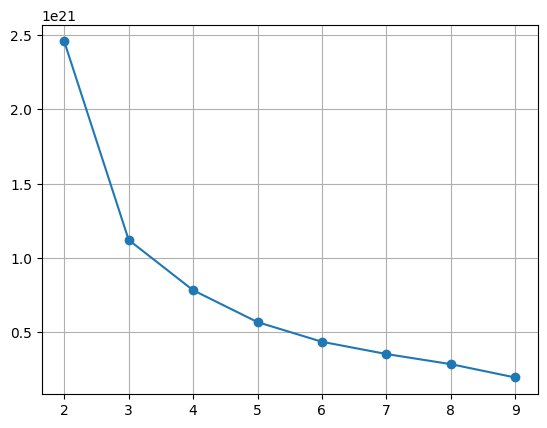

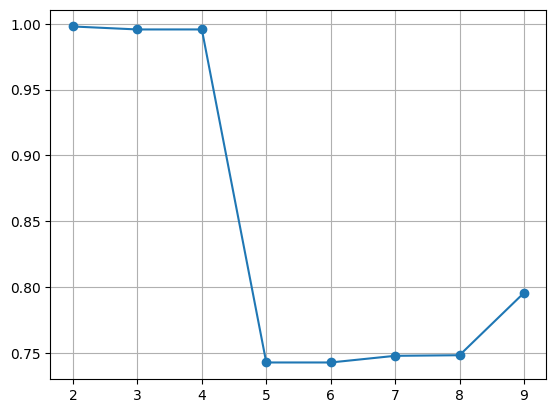

In [3]:
models = []
score1 = []
score2 = []

for i in range(2, 10):
    model = KMeans(n_clusters=i, random_state=123, init='k-means++').fit(data)
    models.append(model)
    score1.append(model.inertia_)
    score2.append(silhouette_score(data, model.labels_))

plt.grid()
plt.plot(np.arange(2, 10), score1, marker='o')
plt.show()

plt.grid()
plt.plot(np.arange(2, 10), score2, marker='o')
plt.show()

## Задание 3
Провести кластеризацию данных с помощью алгоритма иерархической кластеризации.

In [11]:
print('= = = = = = = = [ model_1 ] = = = = = = = =')
data['Cluster'] = models[0].labels_
data['Cluster'].value_counts()
fig = go.Figure(data=[go.Scatter3d(x=data['proto'], y=data['service'], z=data['Attack_type'], mode='markers',
                                   marker_color=data['Cluster'], marker_size=4)])
fig.show()

print('= = = = = = = = [ model_2 ] = = = = = = = =')
data['Cluster'] = models[1].labels_
data['Cluster'].value_counts()
fig = go.Figure(data=[go.Scatter3d(x=data['proto'], y=data['service'], z=data['Attack_type'], mode='markers',
                                   marker_color=data['Cluster'], marker_size=4)])
fig.show()

= = = = = = = = [ model_1 ] = = = = = = = =


= = = = = = = = [ model_2 ] = = = = = = = =


## Задание 4
Провести кластеризацию данных с помощью алгоритма DBSCAN

In [13]:
model3 = DBSCAN(eps=11, min_samples=5).fit(data)
data['Cluster'] = model3.labels_
fig = go.Figure(data=[
    go.Scatter3d(x=data['proto'], y=data['service'], z=data['Attack_type'], mode='markers',
                 marker_color=data['Cluster'], marker_size=4)])
fig.show()